In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
import numpy as np
import optuna
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import optuna
import torch.optim as optim
import gc
import json
import sys

In [4]:
def get_safe_device():
    print(f"Python executable: {sys.executable}")
    print(f"Torch version: {torch.__version__}")
    print(f"Torch CUDA runtime: {torch.version.cuda}")

    if not torch.cuda.is_available():
        print("CUDA no disponible. Se usará CPU.")
        return torch.device("cpu")

    try:
        # Fuerza inicialización real del contexto CUDA
        torch.cuda.init()
        a = torch.randn((256, 256), device="cuda")
        b = torch.randn((256, 256), device="cuda")
        _ = a @ b
        torch.cuda.synchronize()
        print("CUDA smoke test OK (matmul + synchronize).")
        return torch.device("cuda")
    except Exception as e:
        print(f"CUDA no inicializa bien en este kernel ({e}). Se usará CPU.")
        return torch.device("cpu")


device = get_safe_device()
print(f"Ejecutando en {device}")

Python executable: /home/yo/UCM_Trabajos/C-ity-enjoyers/.venv/bin/python
Torch version: 2.10.0+cu128
Torch CUDA runtime: 12.8
CUDA smoke test OK (matmul + synchronize).
Ejecutando en cuda


In [5]:
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent

## Probamos una versión del modelo en la que se entrena un único embedding por distrito y probamos con datos que no dependen del futuro (solo se sabe origen y destino)

In [6]:
df_train_new = pl.read_parquet(path / "data" / "train_tip_new_2.parquet")
df_val_new = pl.read_parquet(path / "data" / "val_tip_new_2.parquet")
df_test_new = pl.read_parquet(path / "data" / "test_tip_new_2.parquet")

In [10]:
df_train_new.schema # datos nuevos

Schema([('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('payment_type', Int8),
        ('VendorID', Int8),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('direction_bucket', Int32),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64)])

In [7]:
class FinalTaxiTipMDN(nn.Module):
    def __init__(
        self,
        num_numeric,
        cat_vocab_sizes,
        num_gaussians=5,
        hidden_dim=128,
        dropout_rate=0.3,
    ):
        super(FinalTaxiTipMDN, self).__init__()
        self.num_gaussians = num_gaussians
        self.cat_vocab_sizes = dict(cat_vocab_sizes)

        # --- 1. CAPA DE ESCALADO (StandardScaler Integrado) ---
        # Registramos buffers (no se entrenan, pero se guardan con el modelo)
        self.register_buffer("num_mean", torch.zeros(num_numeric))
        self.register_buffer("num_std", torch.ones(num_numeric))
        self.register_buffer("temp_max_vals", torch.tensor([12.0, 366.0, 7.0, 24.0]))

        # --- 2. CAPAS DE EMBEDDING PARA CATEGORICAS ---
        # Compartimos la MISMA capa para PULocationID y DOLocationID.
        # Reservamos el ultimo indice como UNK para categorias fuera de rango.
        self.shared_location_cols = ("PULocationID", "DOLocationID")
        pu_vocab = cat_vocab_sizes[self.shared_location_cols[0]]
        do_vocab = cat_vocab_sizes[self.shared_location_cols[1]]
        self.location_vocab_size = max(pu_vocab, do_vocab)
        location_emb_dim = min(50, (self.location_vocab_size + 1) // 2)

        self.location_embedding = nn.Embedding(
            num_embeddings=self.location_vocab_size + 1,
            embedding_dim=location_emb_dim,
        )

        # Embeddings para el resto de categoricas
        self.other_cat_cols = [
            name for name in cat_vocab_sizes if name not in self.shared_location_cols
        ]
        self.embeddings = nn.ModuleDict(
            {
                name: nn.Embedding(
                    num_embeddings=cat_vocab_sizes[name] + 1,
                    embedding_dim=min(50, (cat_vocab_sizes[name] + 1) // 2),
                )
                for name in self.other_cat_cols
            }
        )

        # Calculamos cuantas caracteristicas entran a la red principal:
        # Numericas + (4 temporales * 2 sen/cos = 8) + embeddings
        emb_out_dim = (
            2 * self.location_embedding.embedding_dim
            + sum(emb.embedding_dim for emb in self.embeddings.values())
        )
        input_dim = num_numeric + 8 + emb_out_dim

        # --- 3. RED NEURONAL PRINCIPAL (Backbone MLP) ---
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),  # Estabiliza el entrenamiento
            nn.GELU(),  # Mejor que ReLU
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate),
        )

        # --- 4. CABEZAS DE LA MDN (Las "Montanitas") ---
        # pi: Probabilidad de cada montanita (K valores)
        self.z_pi = nn.Linear(64, num_gaussians)
        # mu: El centro (media) de cada montanita (K valores)
        self.z_mu = nn.Linear(64, num_gaussians)
        # sigma: La anchura (desviacion estandar) de cada montanita (K valores)
        self.z_sigma = nn.Linear(64, num_gaussians)

        self._initialize_weights()

    def _initialize_weights(self):
        """Fuerza a las gaussianas a nacer separadas para evitar Mode Collapse"""
        # esparcimos los centros (mu) entre 0$ y 100$
        mu_init = torch.linspace(0, 1000, self.num_gaussians)

        # Inyectamos estos centros en el 'bias' de la capa mu
        self.z_mu.bias.data.copy_(mu_init)

        # Hacemos que la red arranque con un poco mas de incertidumbre (sigmas mas anchas)
        # Esto evita que cree picos de aguja demasiado pronto
        self.z_sigma.bias.data.fill_(1.0)

    def set_scaler_stats(self, means, stds):
        """Metodo para inyectarle las medias y stds de Train antes de entrenar"""
        self.num_mean.copy_(torch.tensor(means, dtype=torch.float32))
        self.num_std.copy_(torch.tensor(stds, dtype=torch.float32))

    def temporal_sin_cos(self, x_temp):
        """Convierte (month, dayofyear, weekday, hour) en senos y cosenos"""
        # Transformacion circular usando buffer para evitar constantes en tracing
        max_vals = self.temp_max_vals.to(x_temp.device)
        scaled = (x_temp * 2 * math.pi) / max_vals
        sin_cols = torch.sin(scaled)
        cos_cols = torch.cos(scaled)

        # Devolvemos 8 columnas (4 senos, 4 cosenos intercalados o concatenados)
        return torch.cat([sin_cols, cos_cols], dim=1)

    def _safe_shared(self, x):
        return torch.clamp(x, 0, self.location_vocab_size)

    def _safe_cat(self, name, x):
        vocab_size = self.cat_vocab_sizes[name]
        return torch.clamp(x, 0, vocab_size)

    def forward(self, x_num, x_cat, x_temp):
        # 1. Escalar numericas usando los buffers estaticos
        x_num_scaled = (x_num - self.num_mean) / (self.num_std + 1e-7)

        # 2. Transformar temporales a sen/cos
        x_temp_enc = self.temporal_sin_cos(x_temp)

        # 3. Procesar Embeddings con orden fijo para reproducibilidad
        emb_outs = [
            self.location_embedding(self._safe_shared(x_cat[self.shared_location_cols[0]])),
            self.location_embedding(self._safe_shared(x_cat[self.shared_location_cols[1]])),
        ]
        for name in self.other_cat_cols:
            emb_outs.append(self.embeddings[name](self._safe_cat(name, x_cat[name])))
        x_cat_enc = torch.cat(emb_outs, dim=1)

        # 4. Concatenar todo (El vector de caracteristicas final)
        x_combined = torch.cat([x_num_scaled, x_temp_enc, x_cat_enc], dim=1)

        # 5. Pasar por la red principal
        hidden = self.mlp(x_combined)

        # 6. Salidas de la MDN
        pi = F.softmax(self.z_pi(hidden), dim=-1)  # Las probabilidades deben sumar 1
        mu = self.z_mu(hidden)
        # Usamos softplus + un epsilon pequenito para evitar sigmas = 0 (colapso matematico)
        sigma = F.softplus(self.z_sigma(hidden)) + 1e-6

        return pi, mu, sigma

In [8]:
def mdn_loss_fn(pi, mu, sigma, y):
    """Calcula el Negative Log-Likelihood para la MDN de forma estable"""
    # Expandimos y para que encaje con las gaussianas: [batch_size, num_gaussians]
    y_expand = y.unsqueeze(1).expand_as(mu)
    
    # Creamos la distribución normal
    normal_dist = torch.distributions.Normal(mu, sigma)
    
    # log(pi) + log(N(y | mu, sigma))
    log_probs = torch.log(pi + 1e-8) + normal_dist.log_prob(y_expand)
    
    # LogSumExp estabiliza matemáticamente la suma de exponenciales pequeñas
    loss = -torch.logsumexp(log_probs, dim=1)
    
    return loss.mean()

In [22]:
def save_tip_model(
    modelo, params, num_cols, cat_cols, temp_cols,
    nombre_modelo: str, ruta_archivo=path / "models/model_objects_tip/"
):
    """
    Extrae los pesos matemáticos de la MDN y los guarda en disco.
    Importante indicar los parámetros con los que se instanció el modelo.
    """
    ruta_archivo.mkdir(parents=True, exist_ok=True)

    torch.save(modelo.state_dict(), ruta_archivo / f"{nombre_modelo}.pth")

    metadata = {
        "params": params,
        "required_columns": {
            "numerical": num_cols,
            "categorical": cat_cols,
            "temporal": temp_cols,
        }
    }
    with open(ruta_archivo / f"{nombre_modelo}_metadata.json", "w") as fp:
        json.dump(metadata, fp)

    print(f"💾 ¡Modelo guardado con éxito en: {ruta_archivo}!")


def load_tip_model(
    clase_modelo, nombre_modelo, ruta_archivo=path / "models/model_objects_tip/"
):
    """
    Importante que exista en la ruta nombre_modelo.pth y nombre_modelo_params.json
    Importante que esté definido device
    """
    print(f"Cargando modelo desde {ruta_archivo}...")
    try:
        with open(ruta_archivo / f"{nombre_modelo}_metadata.json") as f:
            metadata = json.load(f)

        kwargs_modelo = metadata.get("params", {})
        required_columns = metadata.get("required_columns", {})

    except FileNotFoundError: # Fallback para compatibilidad con versiones anteriores que usaban _params.json
        with open(ruta_archivo / f"{nombre_modelo}_params.json") as f:
            kwargs_modelo = json.load(f)

        required_columns = None
    
    modelo_recuperado = clase_modelo(**kwargs_modelo)

    pesos = torch.load(
        ruta_archivo / f"{nombre_modelo}.pth", map_location=device, weights_only=True
    )

    missing_keys, unexpected_keys = modelo_recuperado.load_state_dict(
        pesos, strict=False
    )
    if missing_keys:
        print(f"Aviso: claves faltantes al cargar (se inicializan por defecto): {missing_keys}")
    if unexpected_keys:
        print(f"Aviso: claves inesperadas en checkpoint: {unexpected_keys}")

    modelo_recuperado.to(device)
    modelo_recuperado.eval()

    print("✅ ¡Modelo reconstruido y listo para predecir!")
    return modelo_recuperado, required_columns

In [11]:
# --- DEFINICIÓN DE COLUMNAS ---
coords_cols = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
dists_cols = ['pickup_dist_nyc', 'dropoff_dist_nyc', 'pickup_dist_chp', 'dropoff_dist_chp', 'pickup_dist_exp', 'dropoff_dist_exp']
base_num_cols = ["distance", "direction"]

# Listas completas
num_cols_manual = base_num_cols + coords_cols + dists_cols
temp_cols_manual = ["month", "dayofyear", "weekday", "hour"]
cat_cols_manual = ["PULocationID", "DOLocationID", "payment_type", "VendorID"]

# --- CREACIÓN DE TENSORES EN MEMORIA (Reemplaza df_train / df_val con tus Polars/Pandas) ---
def df_to_gpu_tensors(df):
    """Convierte un dataframe a tensores y los clava en la GPU inmediatamente"""
    X_num = torch.tensor(df[num_cols_manual].to_numpy(), dtype=torch.float32, device=device)
    X_temp = torch.tensor(df[temp_cols_manual].to_numpy(), dtype=torch.float32, device=device)
    
    X_cat = {col: torch.tensor(df[col].to_numpy(), dtype=torch.long, device=device) for col in cat_cols_manual}
    
    Y = torch.tensor(df["tip_amount"].to_numpy(), dtype=torch.float32, device=device)
    return X_num, X_temp, X_cat, Y

print("Cargando datos a VRAM...")
X_num_train, X_temp_train, X_cat_train, Y_train = df_to_gpu_tensors(df_train_new)
X_num_val, X_temp_val, X_cat_val, Y_val = df_to_gpu_tensors(df_val_new)

vocab_sizes = {
    "PULocationID": 264,
    "DOLocationID": 264,
    "payment_type": 8,
    "VendorID": 5,
}

Cargando datos a VRAM...


In [13]:
def objective(trial):
    # --- 1. HIPERPARÁMETROS A BUSCAR ---
    num_gaussians = trial.suggest_int("num_gaussians", 5, 9)
    hidden_dim = trial.suggest_categorical("hidden_dim", [8, 16, 32, 64])
    lr = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    
    # --- 2. ABLACIÓN DE COLUMNAS NUMÉRICAS ---
    ablation_choice = trial.suggest_categorical("ablation", ["all", "drop_coords", "drop_dists", "drop_all"])
    
    # Determinamos qué índices del tensor X_num usar según la elección
    if ablation_choice == "all":
        active_num_cols = num_cols_manual
    elif ablation_choice == "drop_coords":
        active_num_cols = base_num_cols + dists_cols
    elif ablation_choice == "drop_dists":
        active_num_cols = base_num_cols + coords_cols
    else: # drop_all
        active_num_cols = base_num_cols

    # Extraemos los índices numéricos de la lista general
    active_indices = [num_cols_manual.index(col) for col in active_num_cols]
    active_indices_tensor = torch.tensor(active_indices, device=device)
    
    # --- 3. INICIALIZACIÓN DEL MODELO ---
    modelo = FinalTaxiTipMDN(
        num_numeric=len(active_num_cols), 
        cat_vocab_sizes=vocab_sizes,
        num_gaussians=num_gaussians,
        hidden_dim=hidden_dim
    ).to(device)
    
    optimizer = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    
    # --- 4. CONFIGURACIÓN ENTRENAMIENTO ---
    epochs = 50
    batch_size = 32768
    patience = 6
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    num_train_samples = len(Y_train)
    indices_train = torch.arange(num_train_samples, device=device)
    
    # --- 5. BUCLE DE ENTRENAMIENTO ---
    for epoch in range(epochs):
        modelo.train()
        
        indices_train = indices_train[torch.randperm(num_train_samples, device=device)]
        
        train_loss_acum = 0.0
        
        for start_idx in range(0, num_train_samples, batch_size):
            batch_idx = indices_train[start_idx : start_idx + batch_size]
            
            x_n = X_num_train[batch_idx][:, active_indices_tensor]
            x_t = X_temp_train[batch_idx]
            x_c = {k: v[batch_idx] for k, v in X_cat_train.items()}
            y = Y_train[batch_idx]
            
            optimizer.zero_grad()
            pi, mu, sigma = modelo(x_n, x_c, x_t)
            loss = mdn_loss_fn(pi, mu, sigma, y)
            
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss_acum += loss.item() * len(y)
            
        # --- VALIDACIÓN ---
        modelo.eval()
        with torch.no_grad():
            pi_val, mu_val, sigma_val = modelo(X_num_val[:, active_indices_tensor], X_cat_val, X_temp_val)
            val_loss_final = mdn_loss_fn(pi_val, mu_val, sigma_val, Y_val).item()
        
        # Pruning de Optuna (Corta pruebas inútiles rápidamente)
        trial.report(val_loss_final, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
        # Early Stopping
        if val_loss_final < best_val_loss:
            best_val_loss = val_loss_final
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                # print(f"Early stopping en epoch {epoch}")
                break

    # guardamos el mejor modelo
    if trial.number == 0 or best_val_loss < study.best_value:
        save_tip_model(
            modelo,
            {
                "num_numeric":len(active_num_cols), 
                "cat_vocab_sizes":vocab_sizes,
                "num_gaussians":num_gaussians,
                "hidden_dim":hidden_dim
            },
            active_num_cols,
            cat_cols_manual,
            temp_cols_manual,
            f"mdn_tip_final_optuna_{best_val_loss:.3f}",
        )

    try:
        del modelo
    except NameError:
        pass
                
    return best_val_loss

# --- EJECUCIÓN DE OPTUNA ---
# Usamos pruner de Medianas para cortar runs malos temprano
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study = optuna.create_study(direction="minimize", pruner=pruner)

print("Iniciando búsqueda de hiperparámetros...")
study.optimize(objective, n_trials=30)

print("\n--- MEJOR MODELO ENCONTRADO ---")
print(f"Loss: {study.best_value}")
print("Parámetros:", study.best_params)

[I 2026-04-18 18:11:13,457] A new study created in memory with name: no-name-5d75bf5d-db1a-45c5-928d-cc86b4724a39


Iniciando búsqueda de hiperparámetros...


[I 2026-04-18 18:12:15,361] Trial 0 finished with value: 1.046109676361084 and parameters: {'num_gaussians': 6, 'hidden_dim': 32, 'lr': 0.0001139841026984883, 'weight_decay': 2.4259857061283698e-05, 'ablation': 'drop_coords'}. Best is trial 0 with value: 1.046109676361084.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-04-18 18:13:10,000] Trial 1 finished with value: -1.3785704374313354 and parameters: {'num_gaussians': 7, 'hidden_dim': 16, 'lr': 0.009698526914706063, 'weight_decay': 1.0853810362316064e-06, 'ablation': 'all'}. Best is trial 1 with value: -1.3785704374313354.


...

💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-04-18 18:20:47,172] Trial 11 finished with value: -1.8937911987304688 and parameters: {'num_gaussians': 9, 'hidden_dim': 64, 'lr': 0.004932000563199201, 'weight_decay': 1.731306476496858e-06, 'ablation': 'drop_all'}. Best is trial 10 with value: -1.937703013420105.
[I 2026-04-18 18:21:56,827] Trial 12 finished with value: -1.7337387800216675 and parameters: {'num_gaussians': 9, 'hidden_dim': 64, 'lr': 0.00537762839749847, 'weight_decay': 1.6306882649879959e-06, 'ablation': 'drop_all'}. Best is trial 10 with value: -1.937703013420105.
[I 2026-04-18 18:22:08,790] Trial 13 finished with value: 2.942887544631958 and parameters: {'num_gaussians': 9, 'hidden_dim': 64, 'lr': 0.009436591432019876, 'weight_decay': 5.172133357350322e-06, 'ablation': 'drop_all'}. Best is trial 10 with value: -1.937703013420105.
[I 2026-04-18 18:22:47,545] Trial 14 pruned. 
[I 2026-04-18 18:23:08,327] Trial 15 pruned. 
[I 2026-04-18 18:23:54,969] Trial 16 finished with value: -1.3081032037734985 and parame

💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-04-18 18:27:33,106] Trial 21 pruned. 
[I 2026-04-18 18:28:10,885] Trial 22 pruned. 
[I 2026-04-18 18:28:47,324] Trial 23 pruned. 
[I 2026-04-18 18:29:06,426] Trial 24 pruned. 
[I 2026-04-18 18:29:29,731] Trial 25 pruned. 
[I 2026-04-18 18:29:48,937] Trial 26 pruned. 
[I 2026-04-18 18:30:04,526] Trial 27 pruned. 
[I 2026-04-18 18:30:21,679] Trial 28 pruned. 
[I 2026-04-18 18:30:39,295] Trial 29 pruned. 



--- MEJOR MODELO ENCONTRADO ---
Loss: -2.1182281970977783
Parámetros: {'num_gaussians': 9, 'hidden_dim': 64, 'lr': 0.0042909749901323, 'weight_decay': 5.95180156181179e-05, 'ablation': 'drop_all'}


## Predecimos con el mejor modelo

In [23]:
best_model, required_cols = load_tip_model(
    FinalTaxiTipMDN, f"mdn_tip_final_optuna_-2.118"
)

Cargando modelo desde /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip...
✅ ¡Modelo reconstruido y listo para predecir!


In [15]:
df_zonas = pl.read_csv(
    path / "data" / "taxi_zone_lookup.csv", has_header=True, infer_schema=True
)


def plot_mdn_predictions_real(modelo, b_num, b_cat, b_temp, b_target, num_samples=3):
    modelo.eval()
    with torch.no_grad():
        pi, mu, sigma = modelo(b_num, b_cat, b_temp)

    # Pasamos a CPU y numpy para plotear las curvas
    pi = pi.cpu().numpy()
    mu = mu.cpu().numpy()
    sigma = sigma.cpu().numpy()
    targets = b_target.cpu().numpy()

    num_gaussians = pi.shape[1]

    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4.5 * num_samples))
    if num_samples == 1:
        axes = [axes]

    # Eje X dinámico basado en céntimos
    max_val = max(targets.max(), mu.max())
    x_axis = np.linspace(-50, max_val + 150, 1000)

    for i in range(num_samples):
        ax = axes[i]
        total_pdf = np.zeros_like(x_axis)

        # Dibujamos cada gaussiana con su PESO REAL (pi)
        for k in range(num_gaussians):
            pdf_k = pi[i, k] * norm.pdf(x_axis, mu[i, k], sigma[i, k])
            total_pdf += pdf_k

            etiqueta = f"G{k + 1} ($\mu$={mu[i, k]:.0f}, $\sigma$={sigma[i, k]:.0f}, $\pi$={pi[i, k]:.4f})"
            ax.plot(x_axis, pdf_k, "--", alpha=0.7, lw=1.5, label=etiqueta)

        # Dibujamos la mezcla total en azul fuerte
        ax.plot(
            x_axis, total_pdf, color="blue", lw=2.5, label="Probabilidad Total (MDN)"
        )

        # Marcamos la propina REAL
        ax.axvline(
            targets[i][0],
            color="red",
            linestyle="-",
            lw=2.5,
            label=f"Propina Real ({targets[i][0]:.0f}¢)",
        )

        # Juntamos con los nombres de las localidades
        pu_id = df_zonas.filter(
            pl.col("LocationID") == b_cat["PULocationID"][i].item()
        ).to_dict()["Zone"][0]
        do_id = df_zonas.filter(
            pl.col("LocationID") == b_cat["DOLocationID"][i].item()
        ).to_dict()["Zone"][0]

        # Sacamos el tiempo (El orden en temp_cols era: month, dayofyear, weekday, hour)
        mes = int(b_temp[i, 0].item())
        dia_año = int(b_temp[i, 1].item())
        hora = int(b_temp[i, 3].item())

        titulo_viaje = f"Viaje {i + 1} | Ruta: Zona {pu_id} ➔ Zona {do_id} | Mes: {mes}, Día (año): {dia_año}, Hora: {hora}h"

        ax.set_title(titulo_viaje, fontweight="bold", fontsize=12)
        ax.set_xlabel("Propina en Céntimos (¢)", fontsize=10)
        ax.set_ylabel("Densidad de Probabilidad", fontsize=10)

        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_12207/289799692.py:36: SyntaxWarning: invalid escape sequence '\m'
  etiqueta = f"G{k + 1} ($\mu$={mu[i, k]:.0f}, $\sigma$={sigma[i, k]:.0f}, $\pi$={pi[i, k]:.4f})"
/tmp/ipykernel_12207/289799692.py:36: SyntaxWarning: invalid escape sequence '\s'
  etiqueta = f"G{k + 1} ($\mu$={mu[i, k]:.0f}, $\sigma$={sigma[i, k]:.0f}, $\pi$={pi[i, k]:.4f})"
/tmp/ipykernel_12207/289799692.py:36: SyntaxWarning: invalid escape sequence '\p'
  etiqueta = f"G{k + 1} ($\mu$={mu[i, k]:.0f}, $\sigma$={sigma[i, k]:.0f}, $\pi$={pi[i, k]:.4f})"


In [26]:
num_cols = required_cols["numerical"]
cat_cols = required_cols["categorical"]
temp_cols = required_cols["temporal"]
target_col = "tip_amount"

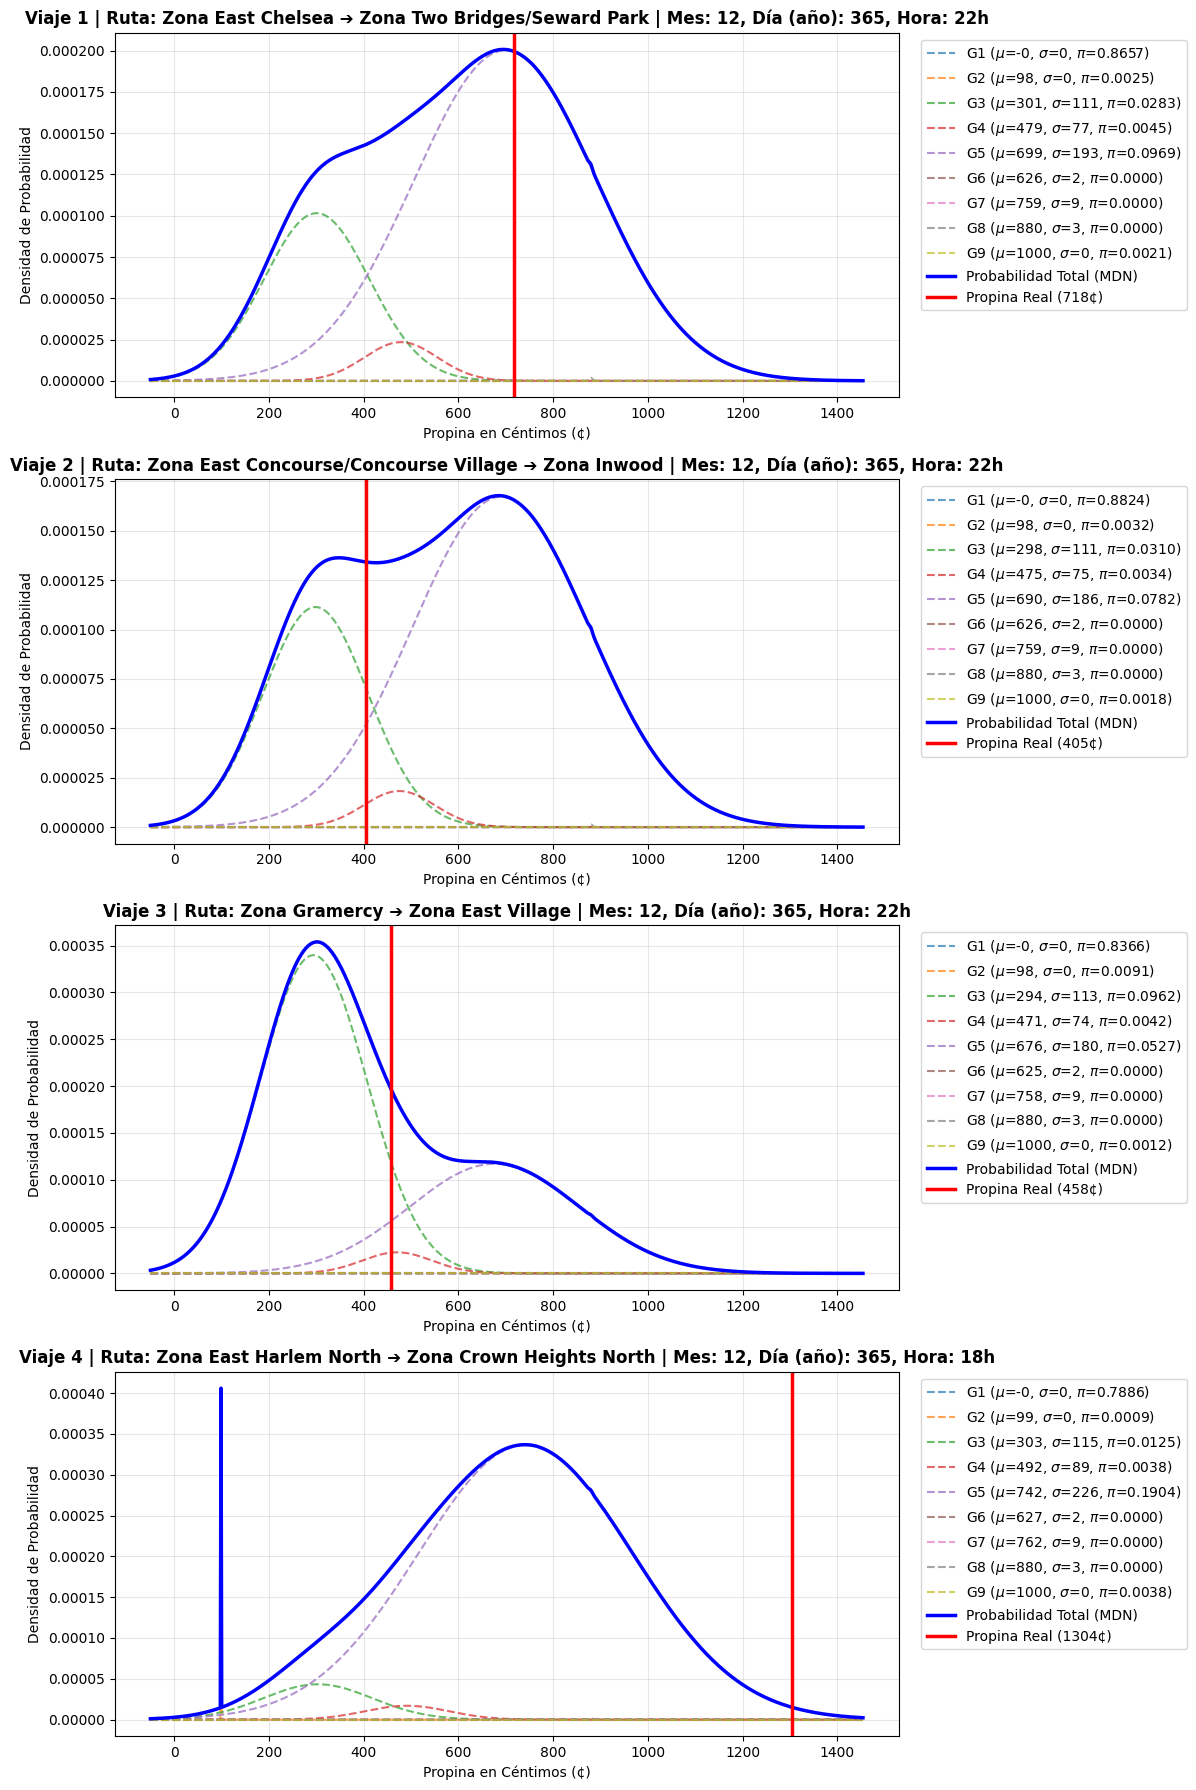

In [29]:
x_num_test = torch.tensor(
    df_test_new.select(num_cols).to_numpy(), dtype=torch.float32, device=device
)
x_temp_test = torch.tensor(
    df_test_new.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_test = torch.tensor(
    df_test_new.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
cat_data_test = {
    col: torch.tensor(df_test_new[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}


mascara_propinas = target_test.squeeze() > 300

x_num_con_propina = x_num_test[mascara_propinas]
x_temp_con_propina = x_temp_test[mascara_propinas]
target_con_propina = target_test[mascara_propinas]

cat_con_propina = {
    col: tensor[mascara_propinas] for col, tensor in cat_data_test.items()
}

plot_mdn_predictions_real(
    best_model,
    x_num_con_propina[:4],
    {k: v[:4] for k, v in cat_con_propina.items()},
    x_temp_con_propina[:4],
    target_con_propina[:4],
    num_samples=4,
)

try:
    del x_num_test, x_temp_test, target_test, cat_data_test
    del x_num_con_propina, x_temp_con_propina, target_con_propina, cat_con_propina
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

Como vemos hay cierta probabilidad de que no dejen propina pero dentro de los que dejan propina vemso que es una distribución multimodal.